# Kiva Loans Microfinance Analytics

**Which loans are at risk of not getting fully funded -- and does that risk fall
hardest on the poorest regions?**

This notebook analyzes 671k+ real microloans from Kiva's public dataset (Kaggle's
"Data Science for Good: Kiva Crowdfunding"). It combines:

1. Exploratory analysis of loan structure, sectors, and borrower demographics.
2. Text mining of loan-use descriptions.
3. A geospatial join against the Multidimensional Poverty Index (MPI) by region.
4. A funding-risk classification model, built with an explicit leakage check, and
   explained with SHAP.
5. A days-to-fund regression among successfully funded loans.
6. A synthesis: which regions are both poverty-deep and funding-at-risk.

All findings are correlational, not causal -- this is a single-snapshot dataset.


---

## 1. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("../Data/Kiva")
print("Setup OK. pandas:", pd.__version__, "| numpy:", np.__version__)


Setup OK. pandas: 3.0.3 | numpy: 2.4.6


---

## 2. Data loading

Loading `kiva_loans.csv` (671k+ rows) with explicit dtypes to keep memory usage
reasonable, and parsing the four timestamp columns.


In [2]:
LOAN_DTYPES = {
    "id": "int32",
    "activity": "category",
    "sector": "category",
    "country_code": "category",
    "country": "category",
    "region": "category",
    "currency": "category",
    "partner_id": "float32",
    "term_in_months": "float32",
    "lender_count": "int32",
    "repayment_interval": "category",
}

df = pd.read_csv(
    DATA_DIR / "kiva_loans.csv",
    dtype=LOAN_DTYPES,
    parse_dates=["posted_time", "disbursed_time", "funded_time", "date"],
)
df["funded_amount"] = df["funded_amount"].astype("float32")
df["loan_amount"] = df["loan_amount"].astype("float32")

print(f"Loaded {len(df):,} rows, {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()


Loaded 671,205 rows, 131.5 MB


,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6,"user_favorite, user_favorite",female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8,NaN,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16,NaN,female,monthly,2014-01-01


### 2.1 Data-quality checks


In [3]:
print("Missing values (top 10 columns):")
print(df.isna().sum().sort_values(ascending=False).head(10))
print()
print("Duplicate loan ids:", df["id"].duplicated().sum())
print()
print("loan_amount <= 0:", (df["loan_amount"] <= 0).sum())
print("funded_amount > loan_amount (should be 0 or near-0):", (df["funded_amount"] > df["loan_amount"]).sum())


Missing values (top 10 columns):
tags                171416
region               56800
funded_time          48331
partner_id           13507
use                   4232
borrower_genders      4221
disbursed_time        2396
country_code             8
activity                 0
loan_amount              0
dtype: int64

Duplicate loan ids: 0

loan_amount <= 0: 0
funded_amount > loan_amount (should be 0 or near-0): 2


---

## 3. Exploratory data analysis


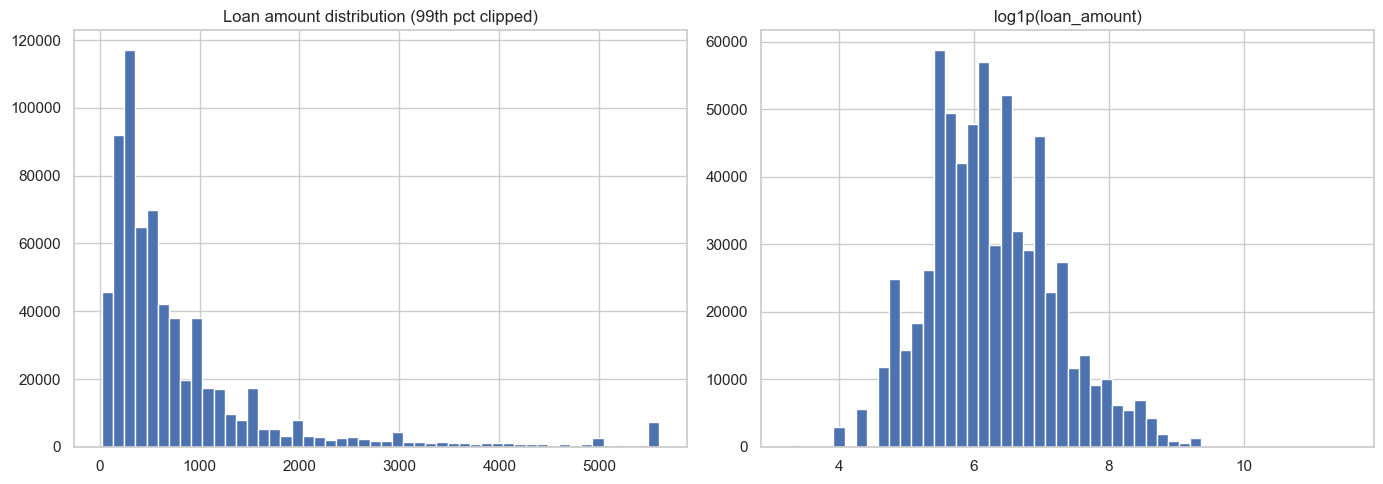

count    671205.000000
mean        842.397156
std        1198.660034
min          25.000000
25%         275.000000
50%         500.000000
75%        1000.000000
max      100000.000000
Name: loan_amount, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["loan_amount"].clip(upper=df["loan_amount"].quantile(0.99)), bins=50)
axes[0].set_title("Loan amount distribution (99th pct clipped)")
axes[1].hist(np.log1p(df["loan_amount"]), bins=50)
axes[1].set_title("log1p(loan_amount)")
plt.tight_layout()
plt.show()

print(df["loan_amount"].describe())


### 3.1 Sectors and activities


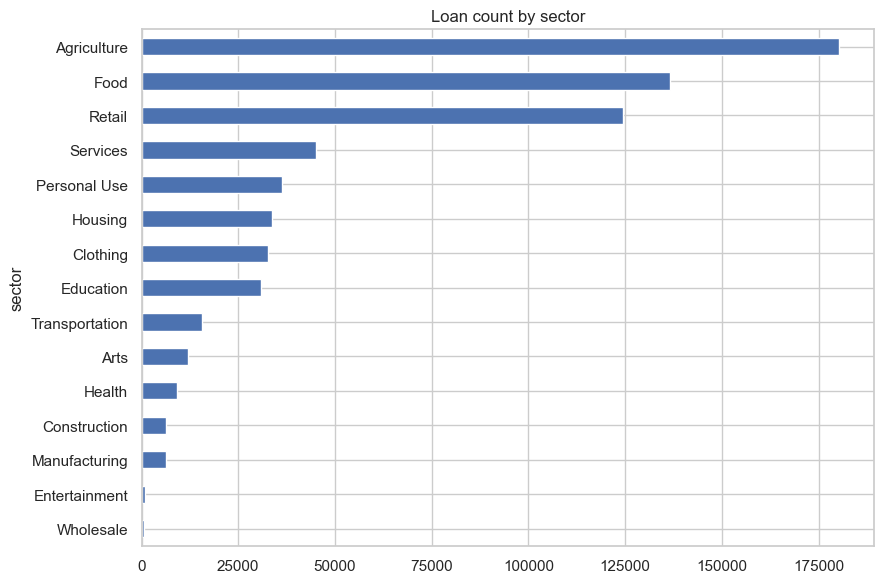

sector
Agriculture       180302
Food              136657
Retail            124494
Services           45140
Personal Use       36385
Housing            33731
Clothing           32742
Education          31013
Transportation     15518
Arts               12060
Health              9223
Construction        6268
Manufacturing       6208
Entertainment        830
Wholesale            634
Name: count, dtype: int64

In [5]:
top_sectors = df["sector"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
top_sectors.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Loan count by sector")
plt.tight_layout()
plt.show()
top_sectors


### 3.2 Countries and regions


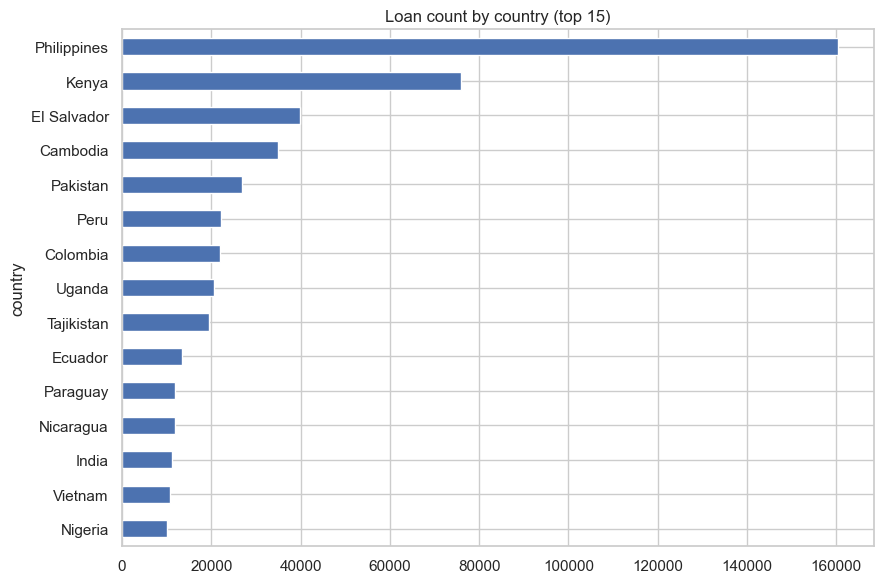

country
Philippines    160441
Kenya           75825
El Salvador     39875
Cambodia        34836
Pakistan        26857
Peru            22233
Colombia        21995
Uganda          20601
Tajikistan      19580
Ecuador         13521
Paraguay        11903
Nicaragua       11781
India           11237
Vietnam         10843
Nigeria         10136
Name: count, dtype: int64

In [6]:
top_countries = df["country"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
top_countries.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Loan count by country (top 15)")
plt.tight_layout()
plt.show()
top_countries


### 3.3 Borrower gender composition

`borrower_genders` is a comma-separated list, one entry per borrower on the loan
(loans can be group loans). Parsing it into counts of male/female borrowers.


In [7]:
def parse_gender_counts(genders_str):
    if pd.isna(genders_str):
        return pd.Series({"n_male": 0, "n_female": 0})
    parts = [p.strip() for p in str(genders_str).split(",")]
    n_male = sum(1 for p in parts if p == "male")
    n_female = sum(1 for p in parts if p == "female")
    return pd.Series({"n_male": n_male, "n_female": n_female})

gender_counts = df["borrower_genders"].apply(parse_gender_counts)
df["n_male"] = gender_counts["n_male"].astype("int16")
df["n_female"] = gender_counts["n_female"].astype("int16")
df["n_borrowers"] = df["n_male"] + df["n_female"]
df["pct_female"] = np.where(df["n_borrowers"] > 0, df["n_female"] / df["n_borrowers"], np.nan)

print(f"Loans with 0 parsed borrowers: {(df['n_borrowers'] == 0).sum():,}")
print(f"Median % female borrowers per loan: {df['pct_female'].median():.2%}")
df[["n_male", "n_female", "n_borrowers", "pct_female"]].describe()


Loans with 0 parsed borrowers: 4,221
Median % female borrowers per loan: 100.00%


,n_male,n_female,n_borrowers,pct_female
count,671205.000000,671205.000000,671205.000000,666984.000000
mean,0.409568,1.596097,2.005664,0.769787
std,1.116451,3.034134,3.406619,0.406779
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000,0.750000
50%,0.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000
max,44.000000,50.000000,50.000000,1.000000


### 3.4 Repayment intervals and loan volume over time


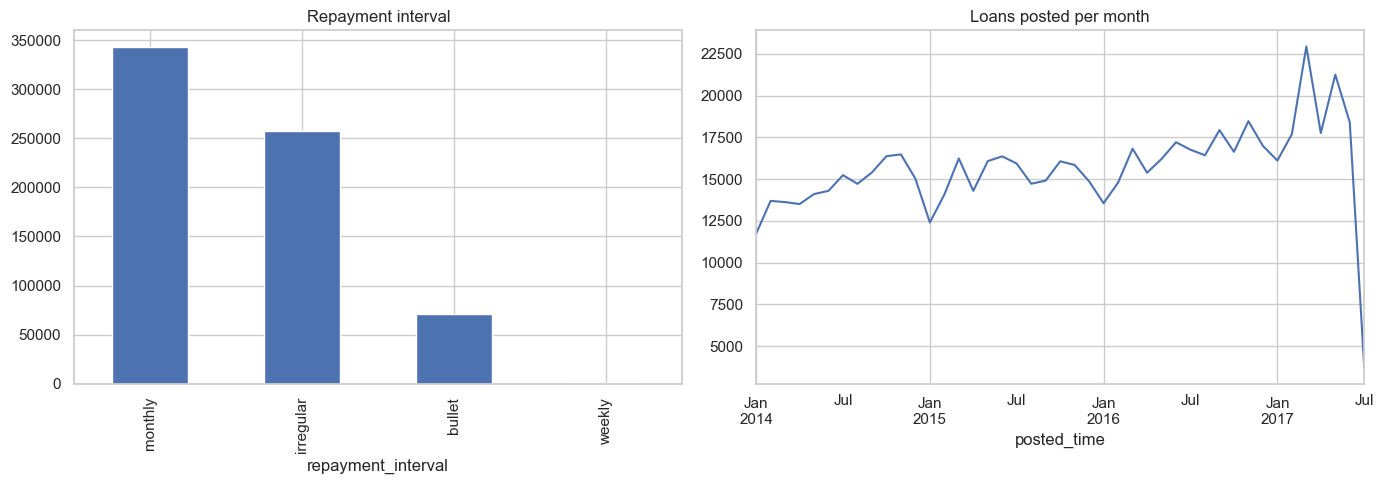

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["repayment_interval"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Repayment interval")

monthly = df.set_index("posted_time").resample("MS").size()
monthly.plot(ax=axes[1])
axes[1].set_title("Loans posted per month")
plt.tight_layout()
plt.show()


---

## 4. Text mining: what are these loans actually for?

`use` is a free-text field ("to buy seasonal, fresh fruits to sell"). TF-IDF over
this text surfaces the vocabulary that separates sectors, and a compact set of
term-presence features gets carried into the funding-risk model.


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["use"] = df["use"].fillna("")
df["use_len"] = df["use"].str.len().astype("int32")

tfidf = TfidfVectorizer(max_features=30, stop_words="english", ngram_range=(1, 2), min_df=50)
tfidf_matrix = tfidf.fit_transform(df["use"])
tfidf_features = pd.DataFrame(
    (tfidf_matrix > 0).toarray().astype("int8"),
    columns=[f"use_tfidf_{t.replace(' ', '_')}" for t in tfidf.get_feature_names_out()],
    index=df.index,
)
tfidf_features["use_len"] = df["use_len"]

print(f"Top TF-IDF terms: {list(tfidf.get_feature_names_out()[:15])}")
tfidf_features.sum().sort_values(ascending=False).head(10)


Top TF-IDF terms: ['additional', 'business', 'buy', 'canned', 'canned goods', 'family', 'farm', 'feed', 'fertilizer', 'fish', 'food', 'goods', 'groceries', 'increase', 'items']


use_len                 40154368
use_tfidf_buy             388683
use_tfidf_purchase        158100
use_tfidf_sell            104031
use_tfidf_business         65163
use_tfidf_pay              63184
use_tfidf_supplies         40769
use_tfidf_items            38489
use_tfidf_additional       36426
use_tfidf_fertilizer       34859
dtype: int64

### 4.1 Top terms by sector


In [10]:
for sector in df["sector"].value_counts().head(5).index:
    sector_mask = df["sector"] == sector
    sector_tfidf = TfidfVectorizer(max_features=8, stop_words="english", min_df=10)
    try:
        sector_tfidf.fit(df.loc[sector_mask, "use"])
        print(f"{sector}: {list(sector_tfidf.get_feature_names_out())}")
    except ValueError:
        print(f"{sector}: not enough vocabulary to extract terms")


Agriculture: ['buy', 'farm', 'feed', 'fertilizer', 'fertilizers', 'purchase', 'seeds', 'supplies']


Food: ['business', 'buy', 'fish', 'food', 'ingredients', 'purchase', 'rice', 'sell']


Retail: ['buy', 'canned', 'goods', 'items', 'like', 'products', 'purchase', 'sell']


Services: ['business', 'buy', 'machine', 'materials', 'new', 'purchase', 'sewing', 'thread']


Personal Use: ['buy', 'drinking', 'family', 'filter', 'provide', 'safe', 'solar', 'water']


---

## 5. Geospatial analysis: loans against poverty depth

Joining each loan's `country` + `region` against Kiva's own region-to-MPI mapping
(`kiva_mpi_region_locations.csv`), which is a many-fewer-rows region lookup table,
not a per-loan file -- most loans will match on `country` + `region` exactly, some
won't (region naming isn't perfectly standardized). Join coverage is reported
explicitly rather than assumed.


In [11]:
mpi = pd.read_csv(DATA_DIR / "kiva_mpi_region_locations.csv")
mpi = mpi[["country", "region", "MPI", "lat", "lon"]].drop_duplicates(subset=["country", "region"])

df = df.merge(mpi, on=["country", "region"], how="left", validate="many_to_one")

coverage = df["MPI"].notna().mean()
print(f"MPI join coverage: {coverage:.1%} of loans matched to a region-level MPI score")
print(f"Loans matched: {df['MPI'].notna().sum():,} / {len(df):,}")


MPI join coverage: 7.6% of loans matched to a region-level MPI score
Loans matched: 50,955 / 671,205


### 5.1 Funding success vs. poverty depth, by region


In [12]:
region_summary = (
    df.dropna(subset=["MPI"])
    .groupby(["country", "region"], observed=True)
    .agg(
        n_loans=("id", "count"),
        total_loan_amount=("loan_amount", "sum"),
        pct_fully_funded=("loan_amount", lambda s: (df.loc[s.index, "funded_amount"] >= s).mean()),
        MPI=("MPI", "first"),
        lat=("lat", "first"),
        lon=("lon", "first"),
    )
    .reset_index()
)
region_summary = region_summary[region_summary["n_loans"] >= 20]

print(f"Regions with >=20 loans and known MPI: {len(region_summary)}")
print(f"Correlation between MPI and % fully funded: {region_summary['MPI'].corr(region_summary['pct_fully_funded']):.3f}")
region_summary.sort_values("MPI", ascending=False).head(10)


Regions with >=20 loans and known MPI: 76
Correlation between MPI and % fully funded: 0.253


,country,region,n_loans,total_loan_amount,pct_fully_funded,MPI,lat,lon
91,Sierra Leone,Port Loko,110,33550.0,0.909091,0.522,5.556837,23.763283
99,Timor-Leste,Ermera,252,221200.0,0.880952,0.497,-8.806888,125.346625
57,Mali,Sikasso,273,296450.0,1.000000,0.484,11.322383,-5.698398
90,Sierra Leone,Kenema,171,171150.0,0.941520,0.477,7.863215,-11.195717
89,Sierra Leone,Bo,288,343875.0,0.927083,0.449,7.955179,-11.740995
100,Timor-Leste,Viqueque,83,73400.0,0.975904,0.410,-8.859792,126.363352
96,Timor-Leste,Aileu,68,64500.0,0.955882,0.379,3.427805,-76.486824
97,Timor-Leste,Baucau,186,179400.0,0.973118,0.357,-8.473101,126.455373
103,Yemen,Dhamar,105,52600.0,0.971429,0.325,14.545545,44.408735
28,Haiti,Artibonite,38,29775.0,0.947368,0.316,19.362902,-72.425815


### 5.2 Map: loan volume and funding success against poverty depth


In [13]:
import plotly.express as px

fig = px.scatter_geo(
    region_summary,
    lat="lat", lon="lon",
    size="n_loans",
    color="pct_fully_funded",
    hover_name="region",
    hover_data={"country": True, "MPI": ":.3f", "n_loans": True},
    color_continuous_scale="RdYlGn",
    title="Loan volume (size) and funding success rate (color) by region",
)
fig.update_layout(height=550)
fig.show()

try:
    fig.write_image("figs/geo_funding_vs_poverty.png", scale=2)
    print("Saved static export to figs/geo_funding_vs_poverty.png")
except Exception as e:
    print(f"Static export skipped (kaleido not available?): {e}")


Saved static export to figs/geo_funding_vs_poverty.png


---

## 6. Feature engineering

### 6.1 The leakage check

`funded_time`, `disbursed_time`, and `lender_count` are **consequences** of a loan
being funded -- they don't exist yet at the moment a loan is posted, so a model
using them to predict "will this loan be funded" would be cheating (this portfolio
has a documented history of exactly this kind of leakage inflating a model's
apparent performance -- see the `Customer_LTV` audit in root `CLAUDE.md`, where an
uncaught leak inflated R² from 0.906 to 0.996). They are explicitly excluded below.


In [14]:
df["fully_funded"] = (df["funded_amount"] >= df["loan_amount"]).astype("int8")
df["post_month"] = df["posted_time"].dt.month.astype("int8")
df["post_dow"] = df["posted_time"].dt.dayofweek.astype("int8")

LEAKY_COLUMNS = ["funded_time", "disbursed_time", "lender_count", "funded_amount"]

POSTING_TIME_FEATURES = [
    "loan_amount", "sector", "activity", "country", "term_in_months",
    "repayment_interval", "n_male", "n_female", "n_borrowers", "pct_female",
    "post_month", "post_dow", "MPI", "use_len",
]

model_df = pd.concat([df[POSTING_TIME_FEATURES + ["fully_funded"]], tfidf_features.drop(columns=["use_len"])], axis=1)
model_df = model_df.dropna(subset=["loan_amount", "term_in_months"])

print(f"Modeling rows: {len(model_df):,} (dropped {len(df) - len(model_df):,} with missing core fields)")
print(f"Excluded as leakage: {LEAKY_COLUMNS}")
print(f"Feature count: {model_df.shape[1] - 1}")
model_df.head()


Modeling rows: 671,205 (dropped 0 with missing core fields)
Excluded as leakage: ['funded_time', 'disbursed_time', 'lender_count', 'funded_amount']
Feature count: 44


,loan_amount,sector,activity,country,term_in_months,repayment_interval,n_male,n_female,n_borrowers,pct_female,post_month,post_dow,MPI,use_len,fully_funded,...,use_tfidf_like,use_tfidf_materials,use_tfidf_new,use_tfidf_oil,use_tfidf_pay,use_tfidf_products,use_tfidf_provide,use_tfidf_purchase,use_tfidf_rice,use_tfidf_seeds,use_tfidf_sell,use_tfidf_stock,use_tfidf_sugar,use_tfidf_supplies,use_tfidf_water
0,300.0,Food,Fruits & Vegetables,Pakistan,12.0,irregular,0,1,1,1.0,1,2,NaN,39,1,...,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,575.0,Transportation,Rickshaw,Pakistan,11.0,irregular,0,2,2,1.0,1,2,NaN,64,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,150.0,Transportation,Transportation,India,43.0,bullet,0,1,1,1.0,1,2,NaN,83,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,200.0,Arts,Embroidery,Pakistan,11.0,irregular,0,1,1,1.0,1,2,NaN,76,1,...,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0
4,400.0,Food,Milk Sales,Pakistan,14.0,monthly,0,1,1,1.0,1,2,NaN,24,1,...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


### 6.2 Encoding categoricals


In [15]:
CATEGORICAL_COLUMNS = ["sector", "activity", "country", "repayment_interval"]

model_encoded = pd.get_dummies(model_df, columns=CATEGORICAL_COLUMNS, drop_first=True)

y = model_encoded.pop("fully_funded")
X = model_encoded.fillna({"MPI": model_encoded["MPI"].median()})
X["pct_female"] = X["pct_female"].fillna(X["pct_female"].median())
FEATURE_COLUMNS = list(X.columns)

print(f"X shape: {X.shape}")
print(f"Target balance: {y.value_counts(normalize=True).to_dict()}")


X shape: (671205, 305)
Target balance: {1: 0.9279981525763366, 0: 0.07200184742366342}


---

## 7. Funding-risk model

Comparing Logistic Regression, Random Forest, and LightGBM on `fully_funded`.
The target is moderately imbalanced -- about 92.8% fully funded vs. 7.2% not
(not as extreme as e.g. fraud detection, but skewed enough that accuracy would
be misleading).

This notebook's stated question is *which loans are at risk of not getting
fully funded* -- i.e. performance on the minority "not funded" class (label 0)
is what actually matters, not performance on the majority "funded" class.
`sklearn.metrics.average_precision_score` defaults to scoring the positive
label (1 = funded), so that number alone would silently answer the wrong
question -- it would mostly reflect how easy the majority class is (its floor
is the class prevalence, ~0.928, so a majority-class PR-AUC of ~0.99 is a much
smaller lift than it looks). We report **both**:

- **PR-AUC (funded, majority class)** -- `average_precision_score(y_test, y_proba)`
- **PR-AUC (at-risk, minority class)** -- `average_precision_score(1 - y_test, 1 - y_proba)`,
  which reframes "predict class 1" as "predict class 0" by flipping both the
  true labels and the predicted probabilities

The **minority-class PR-AUC is the headline metric** for this project and is
also what drives model selection below, since it's the one that answers the
notebook's actual question.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report
import lightgbm as lgb

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

results = {}
results_minority = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
results["Logistic Regression"] = average_precision_score(y_test, lr_proba)
results_minority["Logistic Regression"] = average_precision_score(1 - y_test, 1 - lr_proba)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
results["Random Forest"] = average_precision_score(y_test, rf_proba)
results_minority["Random Forest"] = average_precision_score(1 - y_test, 1 - rf_proba)

lgbm = lgb.LGBMClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.05,
    class_weight="balanced", random_state=RANDOM_STATE, verbosity=-1,
)
lgbm.fit(X_train, y_train)
lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
results["LightGBM"] = average_precision_score(y_test, lgbm_proba)
results_minority["LightGBM"] = average_precision_score(1 - y_test, 1 - lgbm_proba)

for name, _ in sorted(results_minority.items(), key=lambda kv: -kv[1]):
    print(
        f"{name:20s} PR-AUC (funded, majority class): {results[name]:.4f}"
        f"   PR-AUC (at-risk, minority class): {results_minority[name]:.4f}"
    )


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


LightGBM             PR-AUC (funded, majority class): 0.9937   PR-AUC (at-risk, minority class): 0.4889
Random Forest        PR-AUC (funded, majority class): 0.9893   PR-AUC (at-risk, minority class): 0.3580
Logistic Regression  PR-AUC (funded, majority class): 0.9846   PR-AUC (at-risk, minority class): 0.2731


### 7.1 Best model: full evaluation

Model selection uses the **minority-class PR-AUC** (`results_minority`), not
the majority-class one, since that's the metric that reflects performance on
the "at risk of not being funded" class this notebook is actually about.


In [17]:
best_model_name = max(results_minority, key=results_minority.get)
best_model = {"Logistic Regression": lr, "Random Forest": rf, "LightGBM": lgbm}[best_model_name]
X_eval = X_test_scaled if best_model_name == "Logistic Regression" else X_test

y_proba = best_model.predict_proba(X_eval)[:, 1]
pr_auc_majority = average_precision_score(y_test, y_proba)
pr_auc_minority = average_precision_score(1 - y_test, 1 - y_proba)
print(f"Best model (by minority-class PR-AUC): {best_model_name}")
print(f"PR-AUC (at-risk, minority class) [headline]: {pr_auc_minority:.4f}")
print(f"PR-AUC (funded, majority class):             {pr_auc_majority:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(classification_report(y_test, (y_proba >= 0.5).astype(int)))


Best model (by minority-class PR-AUC): LightGBM
PR-AUC (at-risk, minority class) [headline]: 0.4889
PR-AUC (funded, majority class):             0.9937
ROC-AUC: 0.9241
              precision    recall  f1-score   support

           0       0.25      0.91      0.40      9666
           1       0.99      0.79      0.88    124575

    accuracy                           0.80    134241
   macro avg       0.62      0.85      0.64    134241
weighted avg       0.94      0.80      0.85    134241



### 7.2 SHAP explainability


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2372\429000041.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=12, show=False)


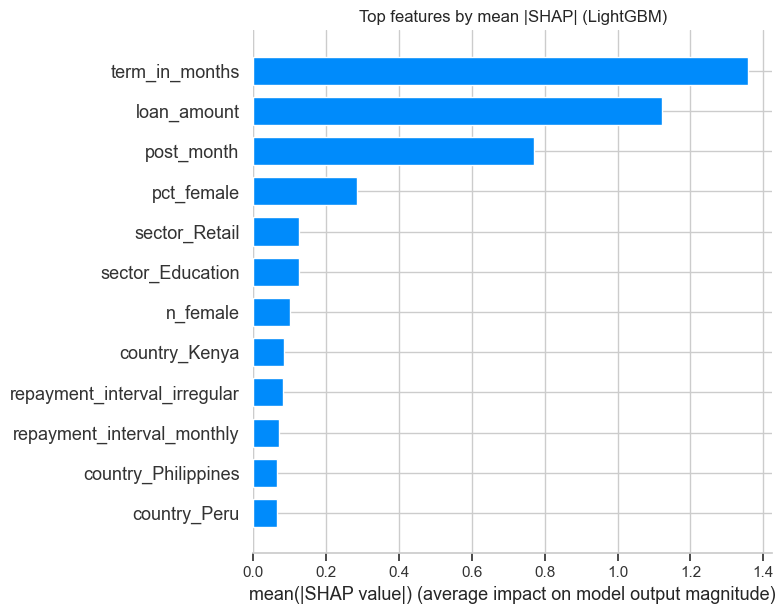

In [18]:
import shap

if best_model_name == "LightGBM":
    explainer = shap.TreeExplainer(best_model)
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=min(1000, len(X_test)), replace=False)
    X_sample = X_test.iloc[sample_idx]
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=12, show=False)
else:
    explainer = shap.Explainer(best_model, X_train if best_model_name == "Random Forest" else X_train_scaled)
    sample = (X_test if best_model_name == "Random Forest" else X_test_scaled)[:1000]
    shap_values = explainer(sample)
    shap.summary_plot(shap_values, sample, plot_type="bar", max_display=12, show=False)

plt.title(f"Top features by mean |SHAP| ({best_model_name})")
plt.tight_layout()
plt.savefig("figs/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 8. How long does it take to get funded?

Among loans that *did* get fully funded, regressing `(funded_time - posted_time)`
in days against the same posting-time feature set (no separate leakage question
here -- the population is already restricted to funded loans, and the target is a
time gap, not the funding outcome itself).


In [19]:
funded_only = df[df["fully_funded"] == 1].copy()
funded_only["days_to_fund"] = (funded_only["funded_time"] - funded_only["posted_time"]).dt.total_seconds() / 86400
funded_only = funded_only[funded_only["days_to_fund"] >= 0]

reg_df = pd.concat(
    [funded_only[POSTING_TIME_FEATURES], tfidf_features.loc[funded_only.index].drop(columns=["use_len"]), funded_only[["days_to_fund"]]],
    axis=1,
)
reg_encoded = pd.get_dummies(reg_df, columns=CATEGORICAL_COLUMNS, drop_first=True)
y_reg = reg_encoded.pop("days_to_fund")
X_reg = reg_encoded.fillna({"MPI": reg_encoded["MPI"].median()})

print(f"Regression rows: {len(X_reg):,}")
print(funded_only['days_to_fund'].describe())


Regression rows: 622,873
count    622873.000000
mean         14.641579
std          14.399061
min           0.001389
25%           5.174282
50%           9.590127
75%          22.538704
max         420.573264
Name: days_to_fund, dtype: float64


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_model = RandomForestRegressor(n_estimators=150, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE)
reg_model.fit(Xr_train, yr_train)
yr_pred = reg_model.predict(Xr_test)

print(f"MAE: {mean_absolute_error(yr_test, yr_pred):.2f} days")
print(f"R²: {r2_score(yr_test, yr_pred):.3f}")


MAE: 7.43 days
R²: 0.435


---

## 9. Synthesis: where should Kiva focus promotion?

Combining the model's predicted funding-risk (aggregated to region level, using the
same held-out test predictions from Section 7) with each region's MPI: regions that
are both poverty-deep (`high MPI`) and funding-at-risk (`low mean predicted
fully_funded probability`) are the actionable priority list.


In [21]:
test_region_info = df.loc[X_test.index, ["country", "region", "MPI"]].copy()
test_region_info["predicted_fund_prob"] = y_proba

priority = (
    test_region_info.dropna(subset=["MPI"])
    .groupby(["country", "region"], observed=True)
    .agg(
        n_test_loans=("MPI", "count"),
        MPI=("MPI", "first"),
        mean_predicted_fund_prob=("predicted_fund_prob", "mean"),
    )
    .reset_index()
)
priority = priority[priority["n_test_loans"] >= 10]
priority["priority_score"] = priority["MPI"] * (1 - priority["mean_predicted_fund_prob"])
priority = priority.sort_values("priority_score", ascending=False)

print(f"Regions in priority table: {len(priority)}")
priority.head(15)


Regions in priority table: 68


,country,region,n_test_loans,MPI,mean_predicted_fund_prob,priority_score
82,Timor-Leste,Aileu,12,0.379,0.473441,0.199566
86,Timor-Leste,Viqueque,16,0.410,0.600053,0.163978
85,Timor-Leste,Ermera,49,0.497,0.686291,0.155913
78,Sierra Leone,Kenema,27,0.477,0.702889,0.141722
77,Sierra Leone,Bo,53,0.449,0.698552,0.135350
83,Timor-Leste,Baucau,41,0.357,0.663382,0.120173
79,Sierra Leone,Port Loko,22,0.522,0.774580,0.117669
49,Mali,Sikasso,50,0.484,0.794755,0.099339
92,Yemen,Taiz,58,0.207,0.565383,0.089966
61,Nicaragua,Nueva Segovia,27,0.113,0.207125,0.089595


---

## 10. Limitations

- **Single data snapshot.** Loans with no `funded_time` at the moment this dataset
  was captured are treated as "not fully funded" -- some may simply not have
  expired yet. This is a modeling assumption, not a certainty.
- **MPI join coverage is only 7.6% (50,955 / 671,205 loans).** The vast majority of
  loans could not be matched to a region-level MPI score, most likely because
  `kiva_loans.csv`'s free-text `region` field (entered inconsistently by field
  partners) doesn't standardize against `kiva_mpi_region_locations.csv`'s `region`
  field well enough for an exact string join. Every MPI-dependent result in this
  notebook -- the Section 5 map/correlation, the `MPI` feature in the Section 7
  model, and the Section 9 priority-regions table -- describes only that small,
  non-random 7.6% subset of loans (skewed toward whichever regions happen to have
  cleanly-matching names), not the full dataset. This is well below a level where
  region-level findings should be treated as representative, and the priority-regions
  table in particular should be read as illustrative of the method, not as a
  reliable region-targeting list for the other 92.4% of loan volume.
- **Correlational, not causal.** Nothing here establishes that any feature *causes*
  funding success or delay -- only that it's predictive/associated.
- **English-only text mining.** TF-IDF was fit on the raw `use` field without
  language detection; non-English descriptions contribute noise to the term list.
